# ICA Cleaning

For each trial:
1. Load raw CSV
2. Fit FastICA on high-pass filtered data (1 Hz)
3. Auto-flag suspicious components (kurtosis, autocorrelation, HF ratio, LF ratio, spectral slope)
4. Plot component time series + power spectra (flagged = red)
5. Prompt for components to exclude
6. Subtract artifact components and save as `tache=gng_clean`

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, sosfiltfilt, welch
from scipy.stats import kurtosis, skew
from sklearn.decomposition import FastICA

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

In [2]:
SUBJECT = 17
TACHE = "gng"
TACHE_OUT = "gng_clean"
DATA_PATH = ROOT / f"data/subject{SUBJECT}"

N_COMP = 15  # ICA components to extract
PLOT_SEC = 30  # seconds of time series shown per component
RANDOM_STATE = 42

# Flagging thresholds
THR_KURTOSIS = 5.0  # excess kurtosis above this → non-Gaussian (eye/EMG)
THR_AUTOCORR = 0.3  # lag-1 autocorrelation below this → noise-like (EMG)
THR_HF_RATIO = 0.35  # power(20-60 Hz) / power(1-60 Hz) above this → EMG
THR_LF_RATIO = 0.6  # power(1-4 Hz)  / power(1-60 Hz) above this → EOG
THR_SLOPE_HI = -0.5  # 1/f slope flatter than this → EMG (too flat)
THR_SLOPE_LO = -3.5  # 1/f slope steeper than this → EOG (too steep)
FLAG_MIN = 2  # flag component if this many criteria are triggered

# Auto-detect trials
ALL_TRIALS = sorted(
    int(p.stem.split("_trial_")[1])
    for p in DATA_PATH.glob(f"subject_{SUBJECT}_tache_{TACHE}_trial_*.csv")
)
# ALL_TRIALS = [11]
# Detect EEG columns from first trial
_df0 = pd.read_csv(
    DATA_PATH / f"subject_{SUBJECT}_tache_{TACHE}_trial_{ALL_TRIALS[0]}.csv",
    sep=None,
    engine="python",
    nrows=3,
)
EEG_COLS = [c for c in _df0.columns if c not in ("timestamp", "button")]

print(f"Trials  : {ALL_TRIALS}")
print(f"Channels: {len(EEG_COLS)} — {EEG_COLS}")

Trials  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Channels: 16 — ['ch1', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7', 'ch8', 'ch9', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch16']


In [3]:
# ── Signal processing ─────────────────────────────────────────────────────────


def hp_filter(X: np.ndarray, fs: float, cutoff: float = 1.0) -> np.ndarray:
    """Zero-phase high-pass filter (N, C)."""
    sos = butter(4, cutoff / (fs / 2.0), btype="high", output="sos")
    return sosfiltfilt(sos, X, axis=0)


def fit_ica(X_hp: np.ndarray, n_comp: int, seed: int):
    """Fit FastICA on HP-filtered data. Returns (S, A, ica)."""
    ica = FastICA(n_components=n_comp, random_state=seed, max_iter=1000, tol=0.005)
    S = ica.fit_transform(X_hp)  # (N, n_comp)
    return S, ica.mixing_, ica  # A = mixing_ shape (n_ch, n_comp)


def apply_ica(
    X_raw: np.ndarray, S: np.ndarray, A: np.ndarray, exclude: list
) -> np.ndarray:
    """Subtract artifact components from raw broadband signal."""
    if not exclude:
        return X_raw.copy()
    exc = np.array(exclude, dtype=int)
    artifact = S[:, exc] @ A[:, exc].T
    return X_raw - artifact


# ── Per-component statistics ──────────────────────────────────────────────────


def component_stats(S: np.ndarray, fs: float) -> list[dict]:
    """
    Compute artifact-detection statistics for each ICA component.

    Returns a list of dicts (one per component) with keys:
        kurt       – excess kurtosis   (high → spiky, eye/EMG)
        autocorr   – lag-1 autocorr    (low  → noise-like, EMG)
        hf_ratio   – power 20-60 Hz / 1-60 Hz  (high → EMG)
        lf_ratio   – power  1-4  Hz / 1-60 Hz  (high → EOG)
        slope      – log-log PSD slope  (flat → EMG, steep → EOG)
    """
    nperseg = min(int(fs * 4), len(S))
    stats = []

    for k in range(S.shape[1]):
        s = S[:, k]

        # Kurtosis (excess)
        kurt_val = float(kurtosis(s, fisher=True))

        # Lag-1 autocorrelation
        ac = float(np.corrcoef(s[:-1], s[1:])[0, 1])

        # Welch PSD
        f, pxx = welch(s, fs=fs, nperseg=nperseg)

        def band_power(lo, hi):
            m = (f >= lo) & (f <= hi)
            return pxx[m].sum()

        total = band_power(1, 60) + 1e-30
        hf = band_power(20, 60) / total
        lf = band_power(1, 4) / total

        # Spectral slope via log-log regression (1–60 Hz)
        mask = (f >= 1) & (f <= 60) & (pxx > 0)
        if mask.sum() > 4:
            lf_x = np.log(f[mask])
            lf_y = np.log(pxx[mask])
            slope = float(np.polyfit(lf_x, lf_y, 1)[0])
        else:
            slope = 0.0

        stats.append(
            dict(kurt=kurt_val, autocorr=ac, hf_ratio=hf, lf_ratio=lf, slope=slope)
        )
    return stats


def auto_flag(stats: list[dict]) -> tuple[list[int], list[str]]:
    """
    Apply threshold rules to component stats.

    Returns:
        flagged  – indices of components triggering >= FLAG_MIN criteria
        reasons  – one-line reason string per component ('' if clean)
    """
    flagged = []
    reasons = []

    for k, st in enumerate(stats):
        hits = []
        if st["kurt"] > THR_KURTOSIS:
            hits.append(f"kurt={st['kurt']:.1f}")
        if st["autocorr"] < THR_AUTOCORR:
            hits.append(f"AC={st['autocorr']:.2f}")
        if st["hf_ratio"] > THR_HF_RATIO:
            hits.append(f"HF={st['hf_ratio']:.2f}")
        if st["lf_ratio"] > THR_LF_RATIO:
            hits.append(f"LF={st['lf_ratio']:.2f}")
        if st["slope"] > THR_SLOPE_HI:
            hits.append(f"slope={st['slope']:.1f}(flat)")
        if st["slope"] < THR_SLOPE_LO:
            hits.append(f"slope={st['slope']:.1f}(steep)")

        reasons.append(", ".join(hits))
        if len(hits) >= FLAG_MIN:
            flagged.append(k)

    return flagged, reasons


def print_stats_table(stats: list[dict], reasons: list[str], flagged: list[int]):
    """Print a compact stats table to the cell output."""
    hdr = f"  {'IC':>3}  {'kurt':>6}  {'AC':>5}  {'HF%':>5}  {'LF%':>5}  {'slope':>6}  flags"
    print(hdr)
    print("  " + "-" * (len(hdr) - 2))
    for k, (st, reason) in enumerate(zip(stats, reasons)):
        marker = "  ◀ FLAG" if k in flagged else ""
        print(
            f"  {k:>3}  {st['kurt']:>6.1f}  {st['autocorr']:>5.2f}  "
            f"{st['hf_ratio']*100:>5.1f}  {st['lf_ratio']*100:>5.1f}  "
            f"{st['slope']:>6.1f}  {reason}{marker}"
        )


# ── Plotting ──────────────────────────────────────────────────────────────────


def plot_components(
    S: np.ndarray, fs: float, trial_n: int, flagged: list[int], reasons: list[str]
):
    """Grid of time series (left) and power spectra (right).
    Flagged components are highlighted in red.
    """
    n_comp = S.shape[1]
    n_plot = min(int(PLOT_SEC * fs), len(S))
    t = np.arange(n_plot) / fs
    nperseg = min(int(fs * 4), len(S))

    fig, axes = plt.subplots(
        n_comp,
        2,
        figsize=(14, n_comp * 1.8),
        gridspec_kw={"width_ratios": [3, 1]},
    )
    fig.suptitle(
        f"Subject {SUBJECT}  ·  {TACHE}  ·  Trial {trial_n}  —  ICA Components\n"
        f"Left: time series (first {PLOT_SEC}s)   Right: power spectrum (0–60 Hz)   "
        f"Red = auto-flagged",
        fontsize=11,
        fontweight="bold",
    )

    for k in range(n_comp):
        ax_ts, ax_ps = axes[k]
        is_flagged = k in flagged
        col_ts = "#c0392b" if is_flagged else "steelblue"
        col_ps = "#e74c3c" if is_flagged else "darkorange"
        bg = "#fff0f0" if is_flagged else "white"

        for ax in (ax_ts, ax_ps):
            ax.set_facecolor(bg)

        # ── time series ──────────────────────────────────────────────────────
        ax_ts.plot(t, S[:n_plot, k], lw=0.5, color=col_ts)
        ax_ts.axhline(0, lw=0.4, color="gray", ls="--")
        label = f"IC {k}"
        if is_flagged:
            label += f"\n{reasons[k]}"
        ax_ts.set_ylabel(
            label,
            rotation=0,
            labelpad=80,
            fontsize=7,
            va="center",
            color=col_ts,
            fontweight="bold" if is_flagged else "normal",
        )
        ax_ts.set_xlim(0, t[-1])
        ax_ts.tick_params(labelsize=7)
        ax_ts.yaxis.set_major_locator(plt.MaxNLocator(3))
        if k < n_comp - 1:
            ax_ts.set_xticklabels([])
        else:
            ax_ts.set_xlabel("Time (s)", fontsize=8)

        # ── power spectrum ────────────────────────────────────────────────────
        f_ax, pxx = welch(S[:, k], fs=fs, nperseg=nperseg)
        mask = f_ax <= 60
        ax_ps.semilogy(f_ax[mask], pxx[mask], lw=0.9, color=col_ps)
        ax_ps.axvspan(20, 60, alpha=0.08, color="red")  # EMG band
        ax_ps.axvspan(1, 4, alpha=0.08, color="blue")  # EOG band
        ax_ps.set_xlim(0, 60)
        ax_ps.tick_params(labelsize=7)
        ax_ps.yaxis.set_major_locator(plt.MaxNLocator(3))
        if k < n_comp - 1:
            ax_ps.set_xticklabels([])
        else:
            ax_ps.set_xlabel("Freq (Hz)", fontsize=8)

    plt.tight_layout()
    plt.show()


print("Helpers ready.")

Helpers ready.


## Artifact guide

| Artifact | Time series | Power spectrum | Statistics |
|---|---|---|---|
| **Eye blinks (EOG)** | Large slow spikes | Strong peak < 4 Hz | high kurt, high LF%, steep slope |
| **Eye movements** | Step-like slow drifts | Dominant low-freq | high LF%, steep slope |
| **EMG / muscle** | High-freq bursts | Elevated > 20 Hz, flat | high HF%, low AC, flat slope |
| **Cardiac (ECG)** | Regular ~1 Hz spikes | Sharp peak ~1 Hz | high kurt |
| **Electrode pop** | Sudden offset/jump | Broadband | high kurt, low AC |

Auto-flag triggers when **≥ 2 criteria** exceed thresholds. Flagged components are shown in **red**.

Enter component indices as a comma-separated list (e.g. `0,3,7`) or press **Enter** to accept the auto-suggestion.


  Trial 0 / 12
  52139 samples  FS≈246 Hz  duration=211.9s  presses=29
  Fitting ICA (15 components) … done.

  Auto-flagged: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

   IC    kurt     AC    HF%    LF%   slope  flags
  -----------------------------------------------
    0    28.2   0.97    3.4   88.2    -1.8  kurt=28.2, LF=0.88  ◀ FLAG
    1    23.3   0.91   11.1   78.6    -1.5  kurt=23.3, LF=0.79  ◀ FLAG
    2    -0.4   0.27   97.5    1.2    -0.3  AC=0.27, HF=0.97, slope=-0.3(flat)  ◀ FLAG
    3    29.1   0.98    2.3   92.9    -2.2  kurt=29.1, LF=0.93  ◀ FLAG
    4   110.3   0.98    2.5   78.9    -2.0  kurt=110.3, LF=0.79  ◀ FLAG
    5    17.0   0.96    4.2   88.0    -2.1  kurt=17.0, LF=0.88  ◀ FLAG
    6   275.5   0.98    3.3   82.9    -2.1  kurt=275.5, LF=0.83  ◀ FLAG
    7   124.9   0.96    4.2   92.7    -2.0  kurt=124.9, LF=0.93  ◀ FLAG
    8    23.3   0.97    3.7   89.3    -2.1  kurt=23.3, LF=0.89  ◀ FLAG
    9   206.1   0.91   13.1   64.9    -2.3  kurt=206.1, LF=0.65

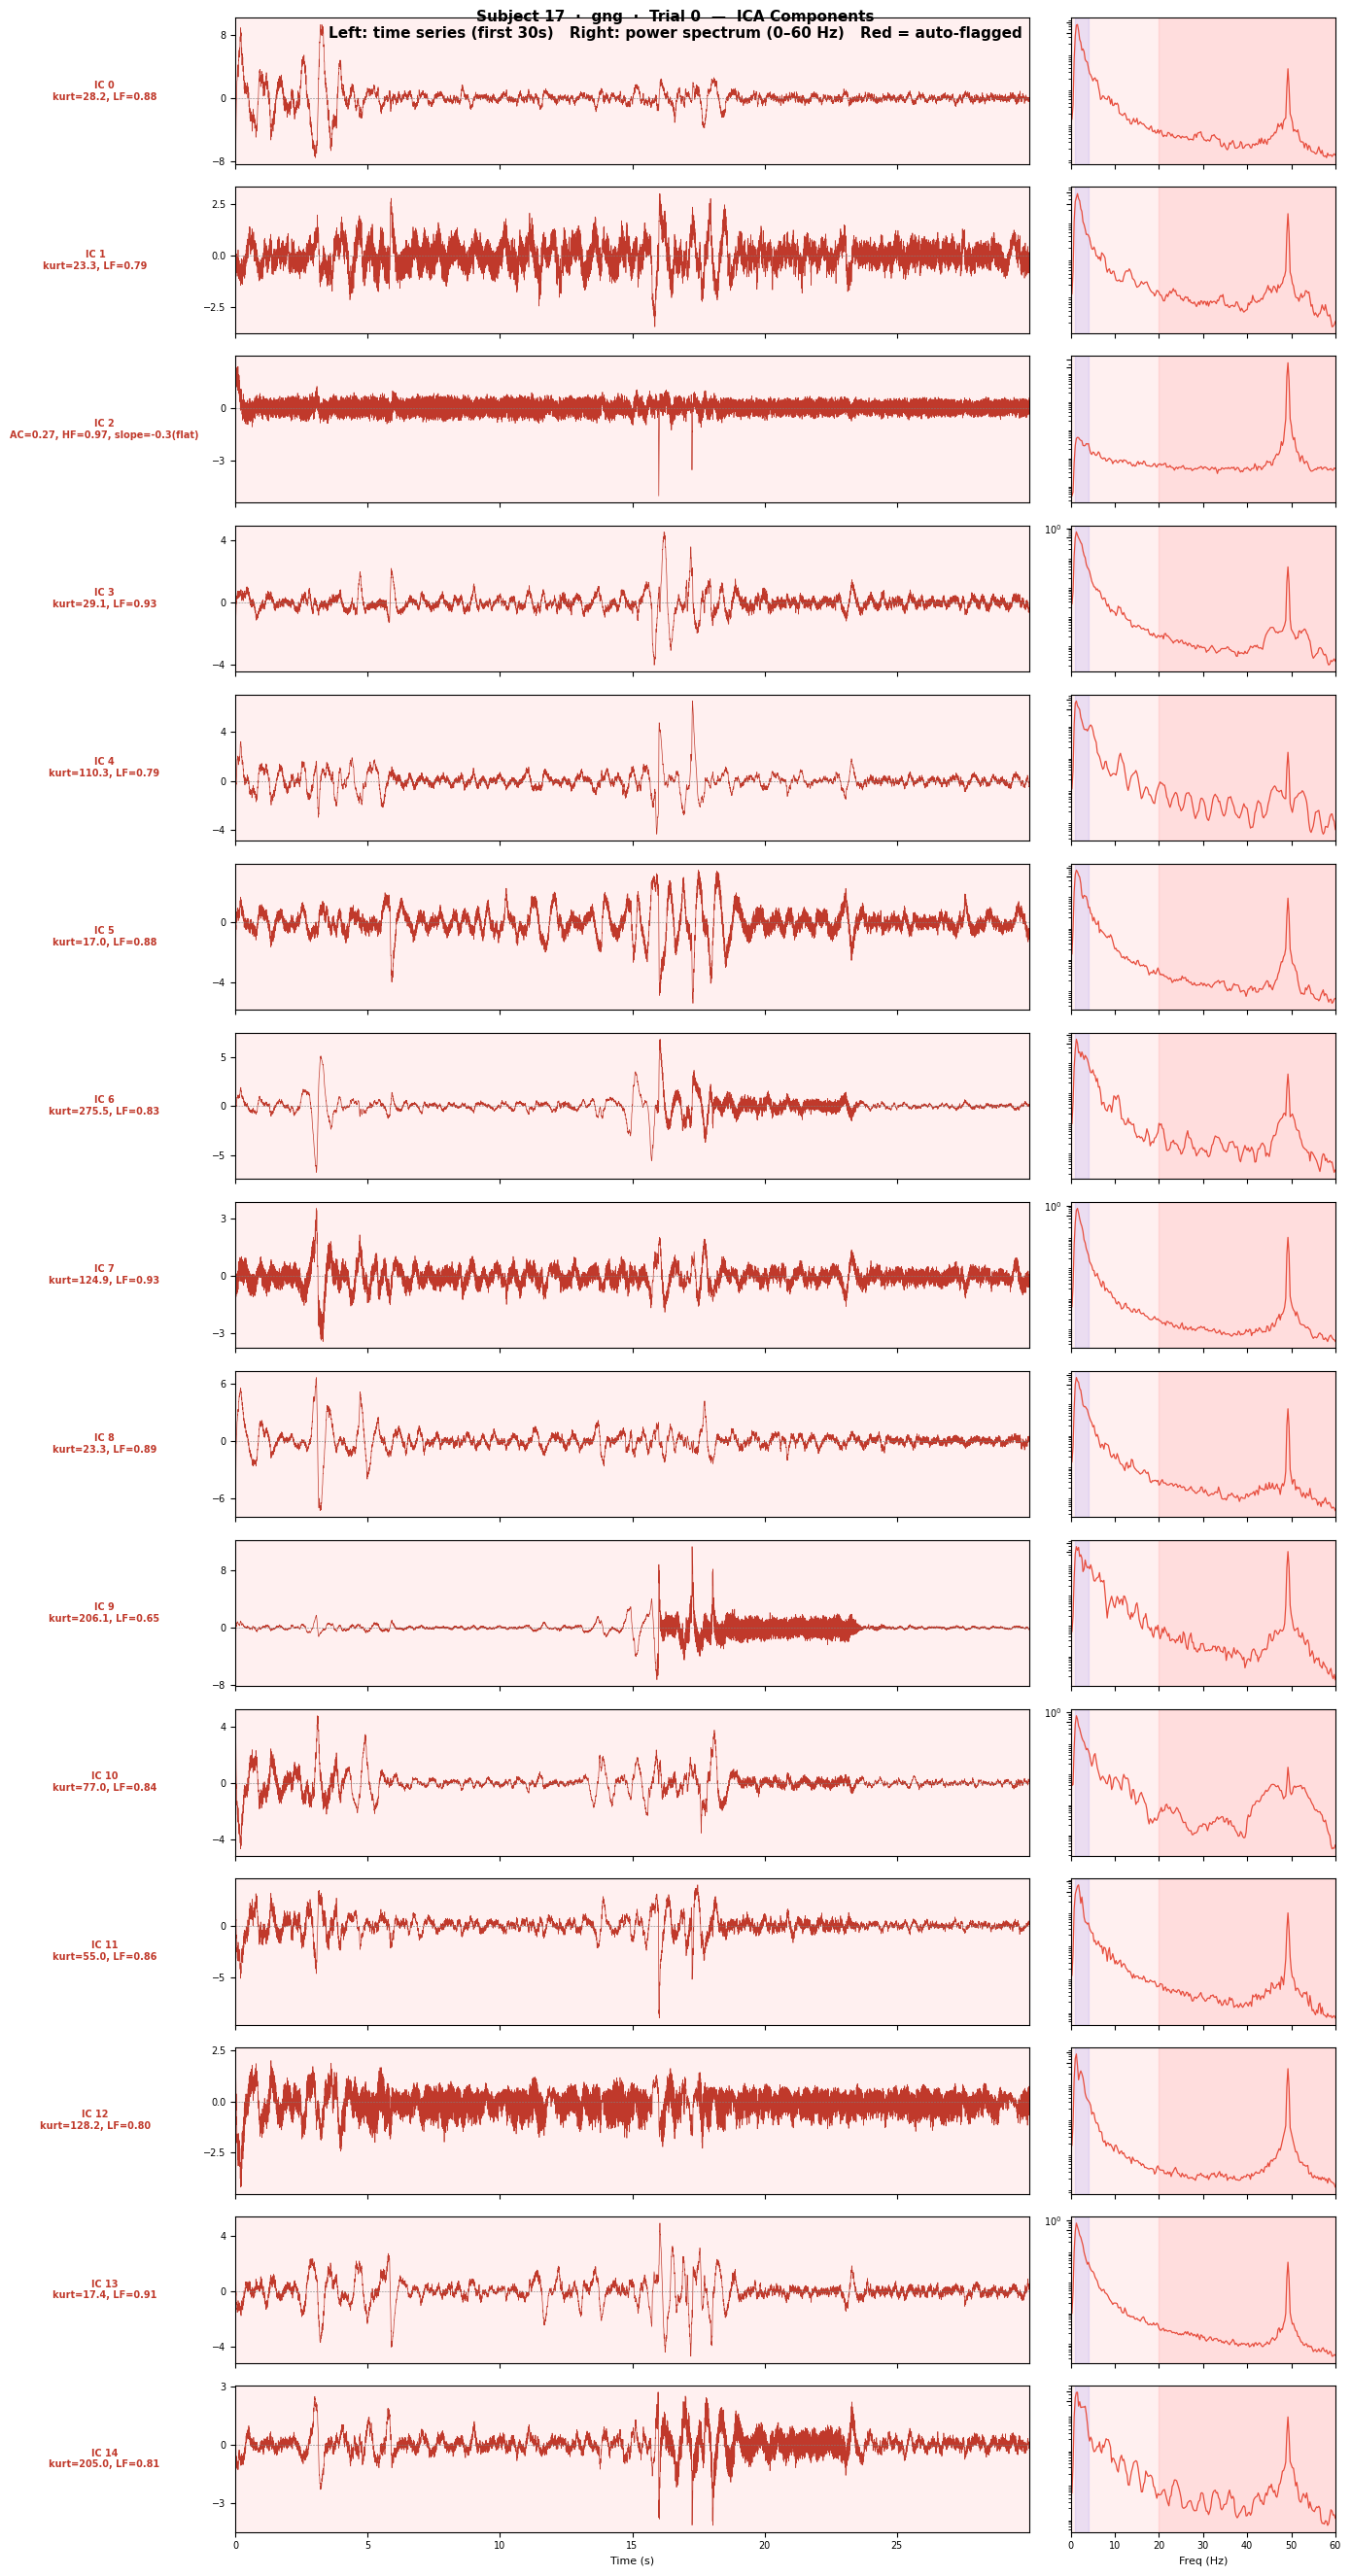


  Components to exclude [auto-suggestion: 0,1,2,3,4,5,6,7,8,9,10,11,12,13,14] (Enter to accept, or type your own list):  


  Accepted auto-suggestion: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  → removed IC[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  ·  saved subject_17_tache_gng_clean_trial_0.csv

  Trial 1 / 12
  51648 samples  FS≈250 Hz  duration=206.6s  presses=32
  Fitting ICA (15 components) … done.

  Auto-flagged: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

   IC    kurt     AC    HF%    LF%   slope  flags
  -----------------------------------------------
    0    65.0   0.97    3.7   85.5    -2.0  kurt=65.0, LF=0.85  ◀ FLAG
    1    89.8   1.00    0.3   94.5    -2.8  kurt=89.8, LF=0.95  ◀ FLAG
    2   859.2   0.99    1.6   88.0    -2.3  kurt=859.2, LF=0.88  ◀ FLAG
    3    21.6   0.87   19.2   70.5    -1.8  kurt=21.6, LF=0.71  ◀ FLAG
    4    10.1   0.95    7.1   87.6    -1.9  kurt=10.1, LF=0.88  ◀ FLAG
    5     9.2   0.98    2.5   91.5    -2.1  kurt=9.2, LF=0.92  ◀ FLAG
    6   239.8   0.99    1.8   84.8    -2.3  kurt=239.8, LF=0.85  ◀ FLAG
    7     7.8   0.86   19.0   

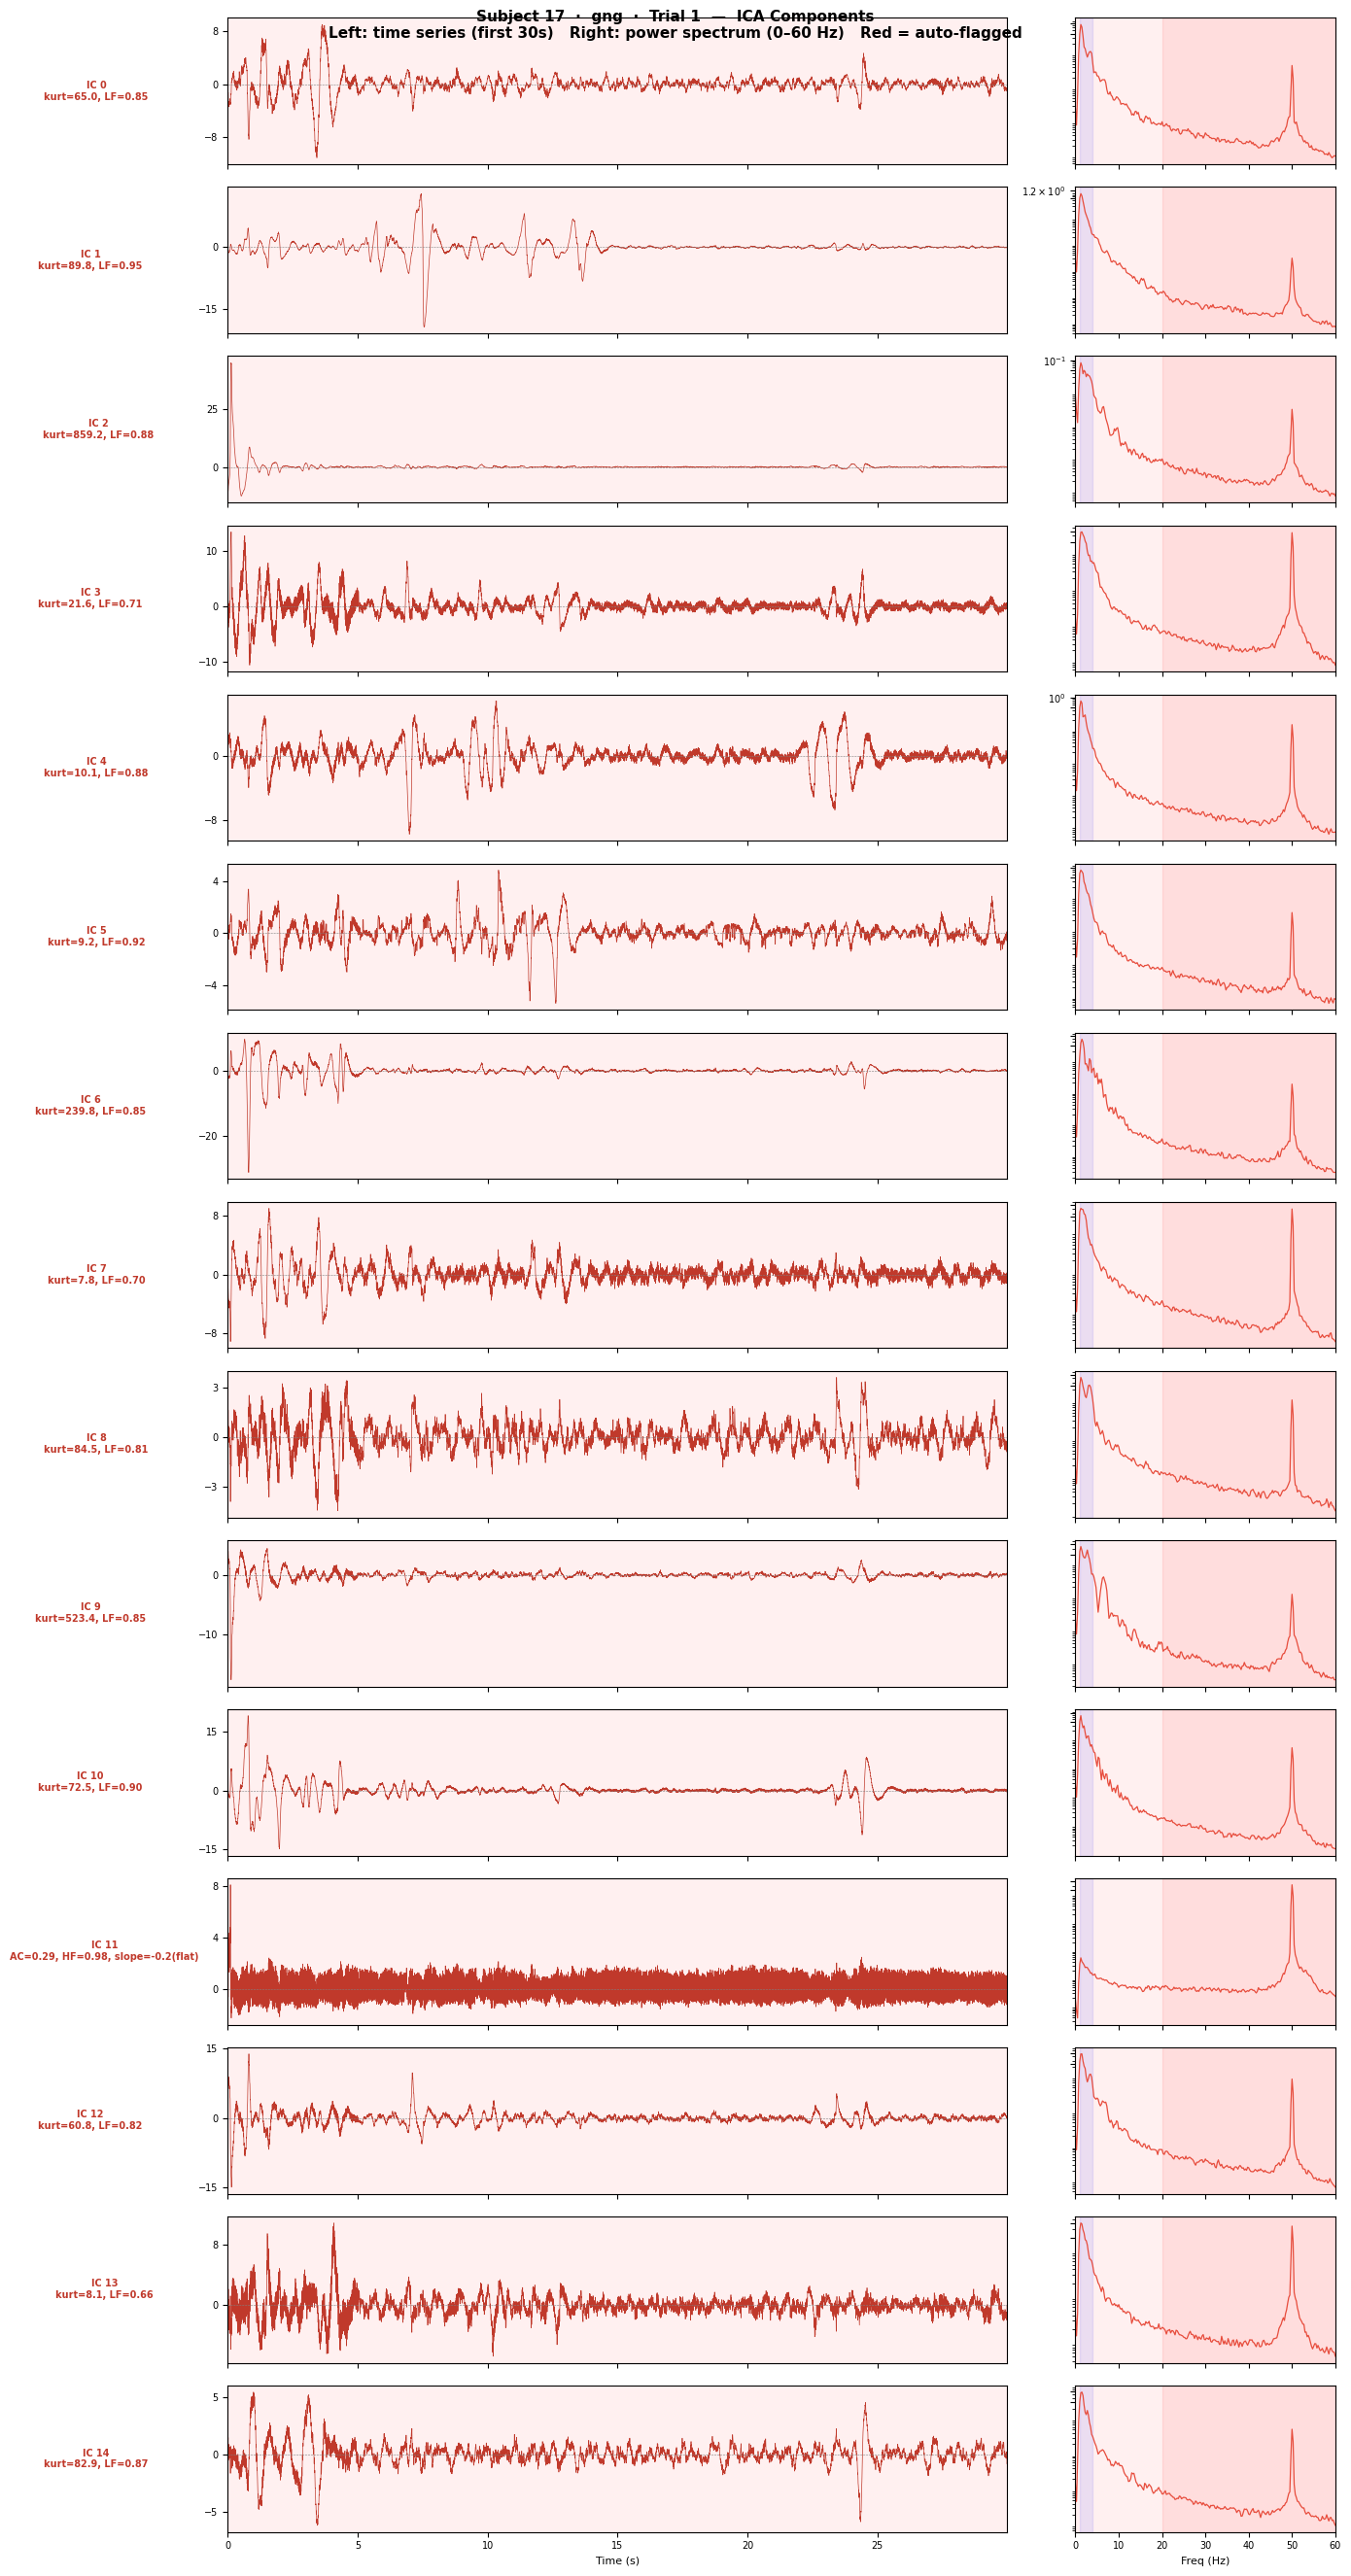


  Components to exclude [auto-suggestion: 0,1,2,3,4,5,6,7,8,9,10,11,12,13,14] (Enter to accept, or type your own list):  


  Accepted auto-suggestion: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  → removed IC[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  ·  saved subject_17_tache_gng_clean_trial_1.csv

  Trial 2 / 12
  51926 samples  FS≈249 Hz  duration=208.5s  presses=28
  Fitting ICA (15 components) … done.

  Auto-flagged: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

   IC    kurt     AC    HF%    LF%   slope  flags
  -----------------------------------------------
    0    72.6   0.89   11.8   74.5    -1.6  kurt=72.6, LF=0.74  ◀ FLAG
    1    69.1   0.98    2.2   89.8    -2.0  kurt=69.1, LF=0.90  ◀ FLAG
    2     8.5   0.98    2.7   83.1    -1.9  kurt=8.5, LF=0.83  ◀ FLAG
    3    34.3   0.99    1.8   86.2    -1.9  kurt=34.3, LF=0.86  ◀ FLAG
    4    20.5   0.97    2.8   86.6    -1.9  kurt=20.5, LF=0.87  ◀ FLAG
    5   129.4   0.87   18.8   78.3    -1.8  kurt=129.4, LF=0.78  ◀ FLAG
    6    40.0   0.96    4.2   78.7    -1.7  kurt=40.0, LF=0.79  ◀ FLAG
    7   107.8   0.97    3.3   8

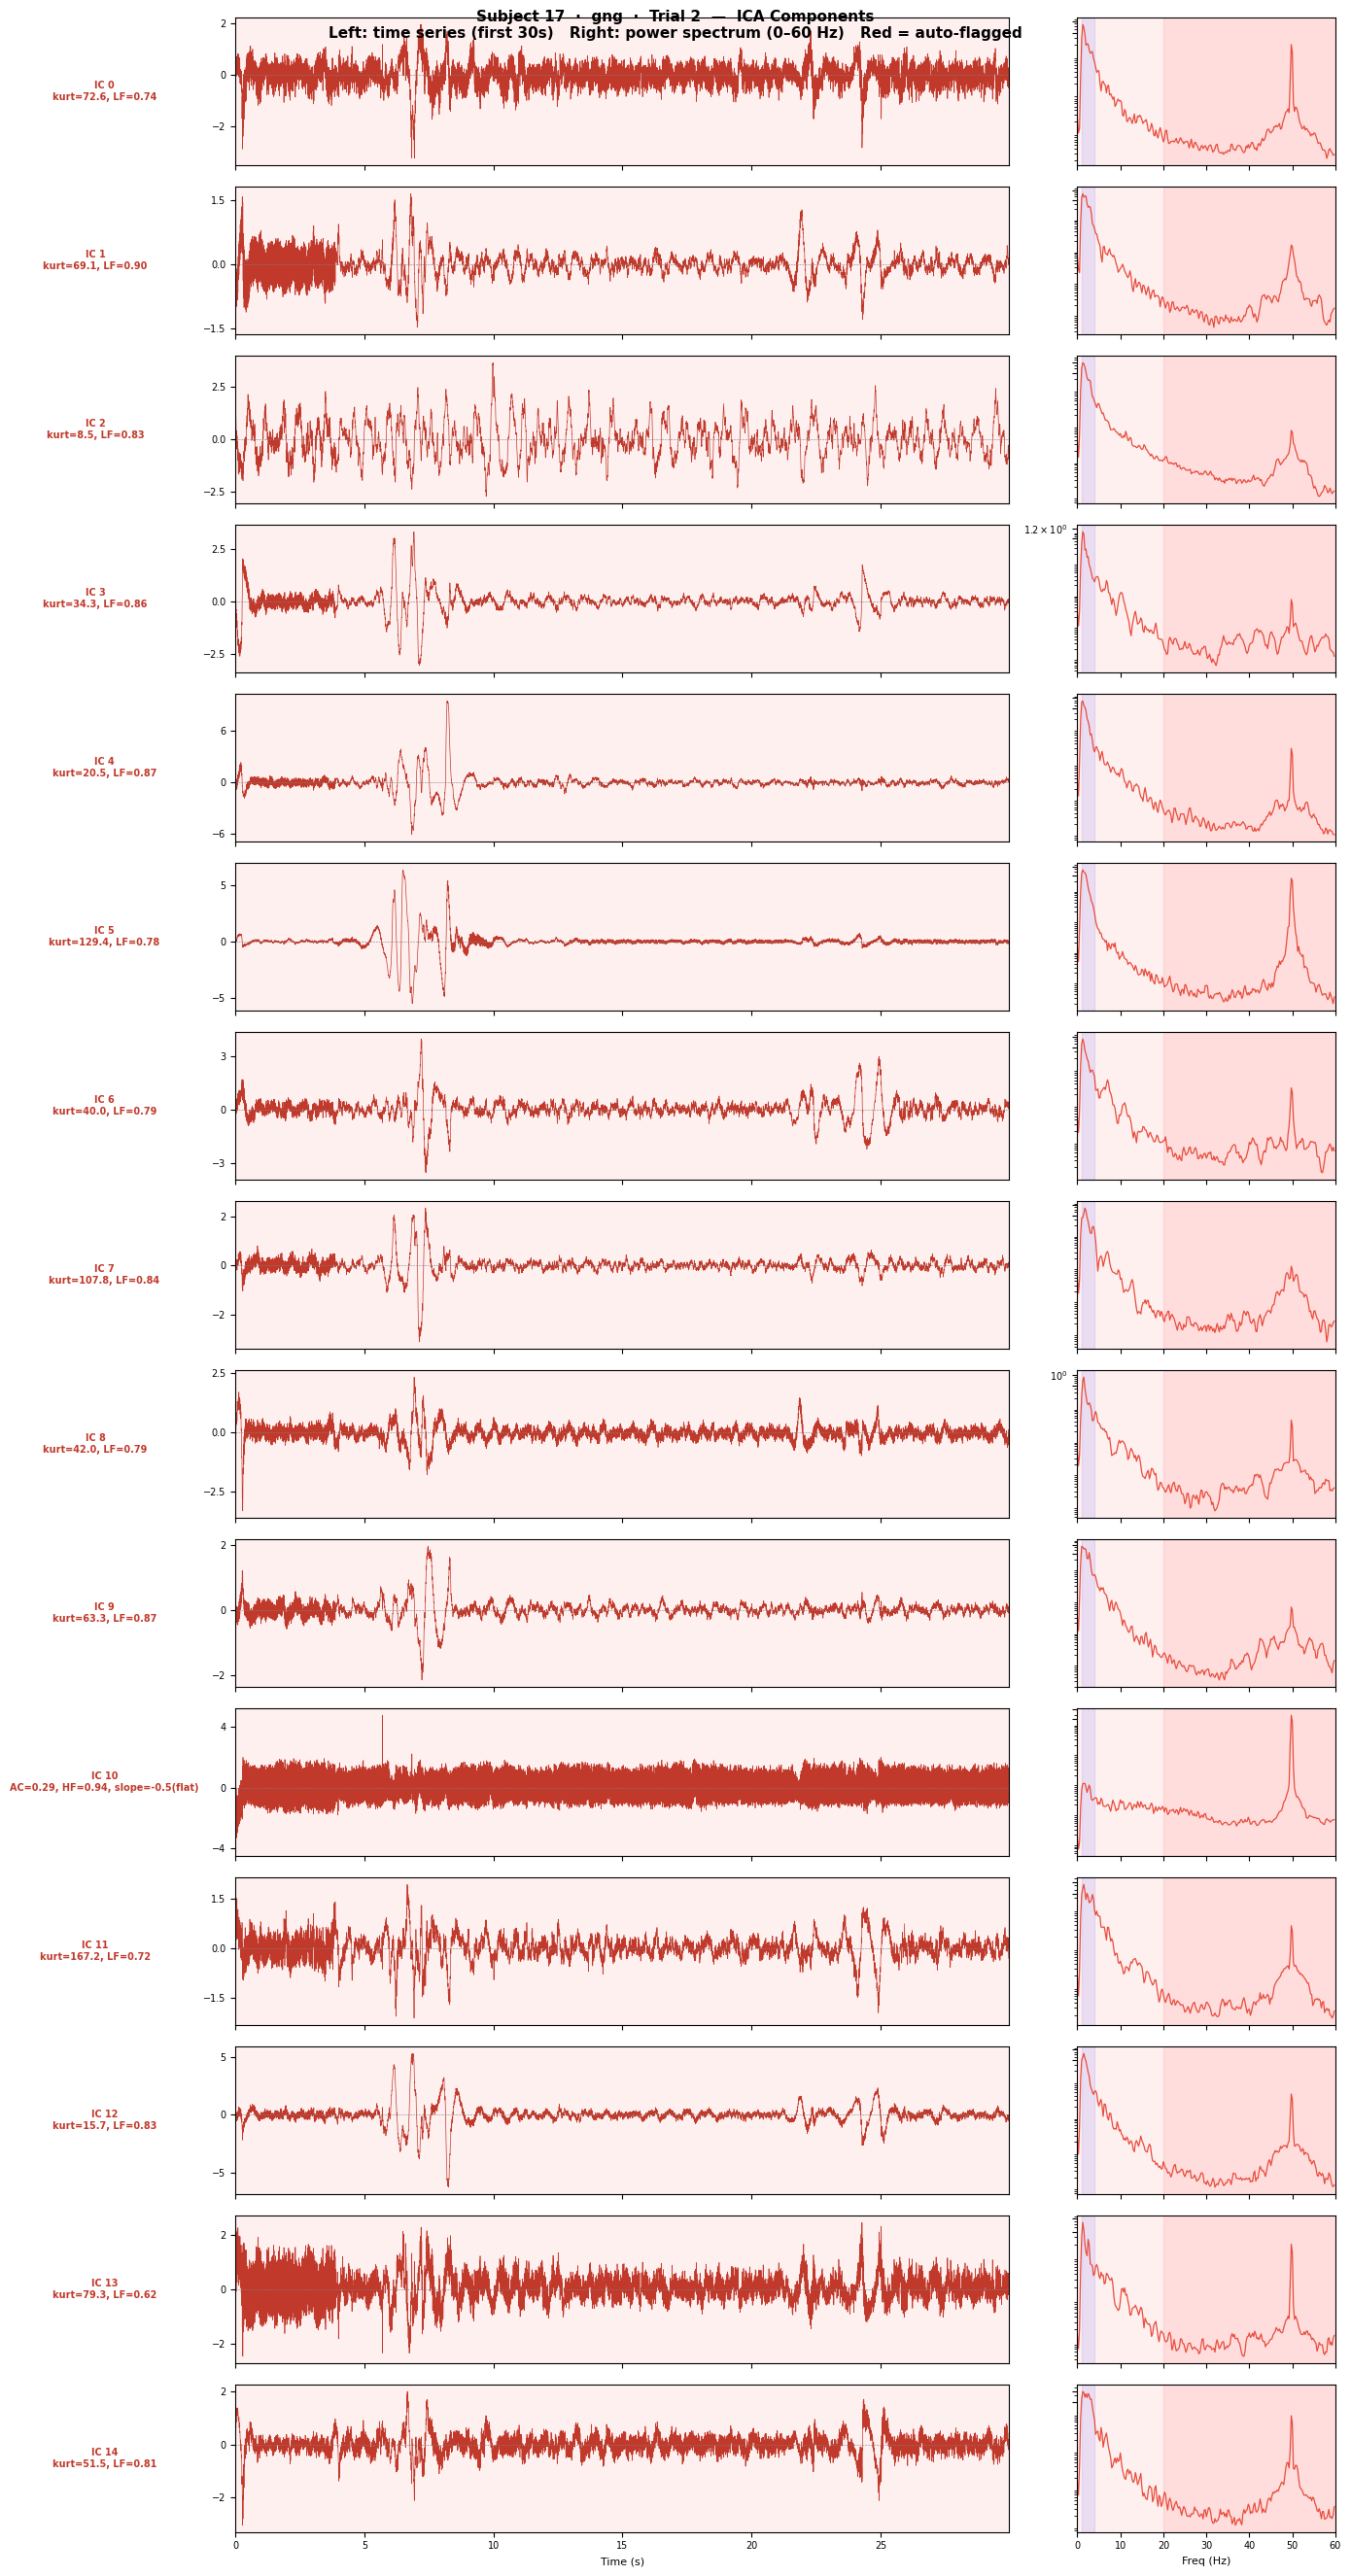


  Components to exclude [auto-suggestion: 0,1,2,3,4,5,6,7,8,9,10,11,12,13,14] (Enter to accept, or type your own list):  


  Accepted auto-suggestion: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
  → removed IC[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  ·  saved subject_17_tache_gng_clean_trial_2.csv

  Trial 3 / 12
  52063 samples  FS≈250 Hz  duration=208.3s  presses=26
  Fitting ICA (15 components) … done.

  Auto-flagged: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

   IC    kurt     AC    HF%    LF%   slope  flags
  -----------------------------------------------
    0   107.0   0.72   41.0   44.4    -1.5  kurt=107.0, HF=0.41  ◀ FLAG
    1   418.2   0.90    3.6   81.3    -2.1  kurt=418.2, LF=0.81  ◀ FLAG
    2   392.3   0.88    5.2   87.7    -2.0  kurt=392.3, LF=0.88  ◀ FLAG
    3  2863.7   0.75    4.9   80.0    -2.3  kurt=2863.7, LF=0.80  ◀ FLAG
    4    24.9   0.94    7.5   77.6    -1.9  kurt=24.9, LF=0.78  ◀ FLAG
    5   385.2   0.91    2.9   81.3    -2.4  kurt=385.2, LF=0.81  ◀ FLAG
    6    63.9   0.95    6.9   81.1    -2.2  kurt=63.9, LF=0.81  ◀ FLAG
    7    27.4   0.97    3

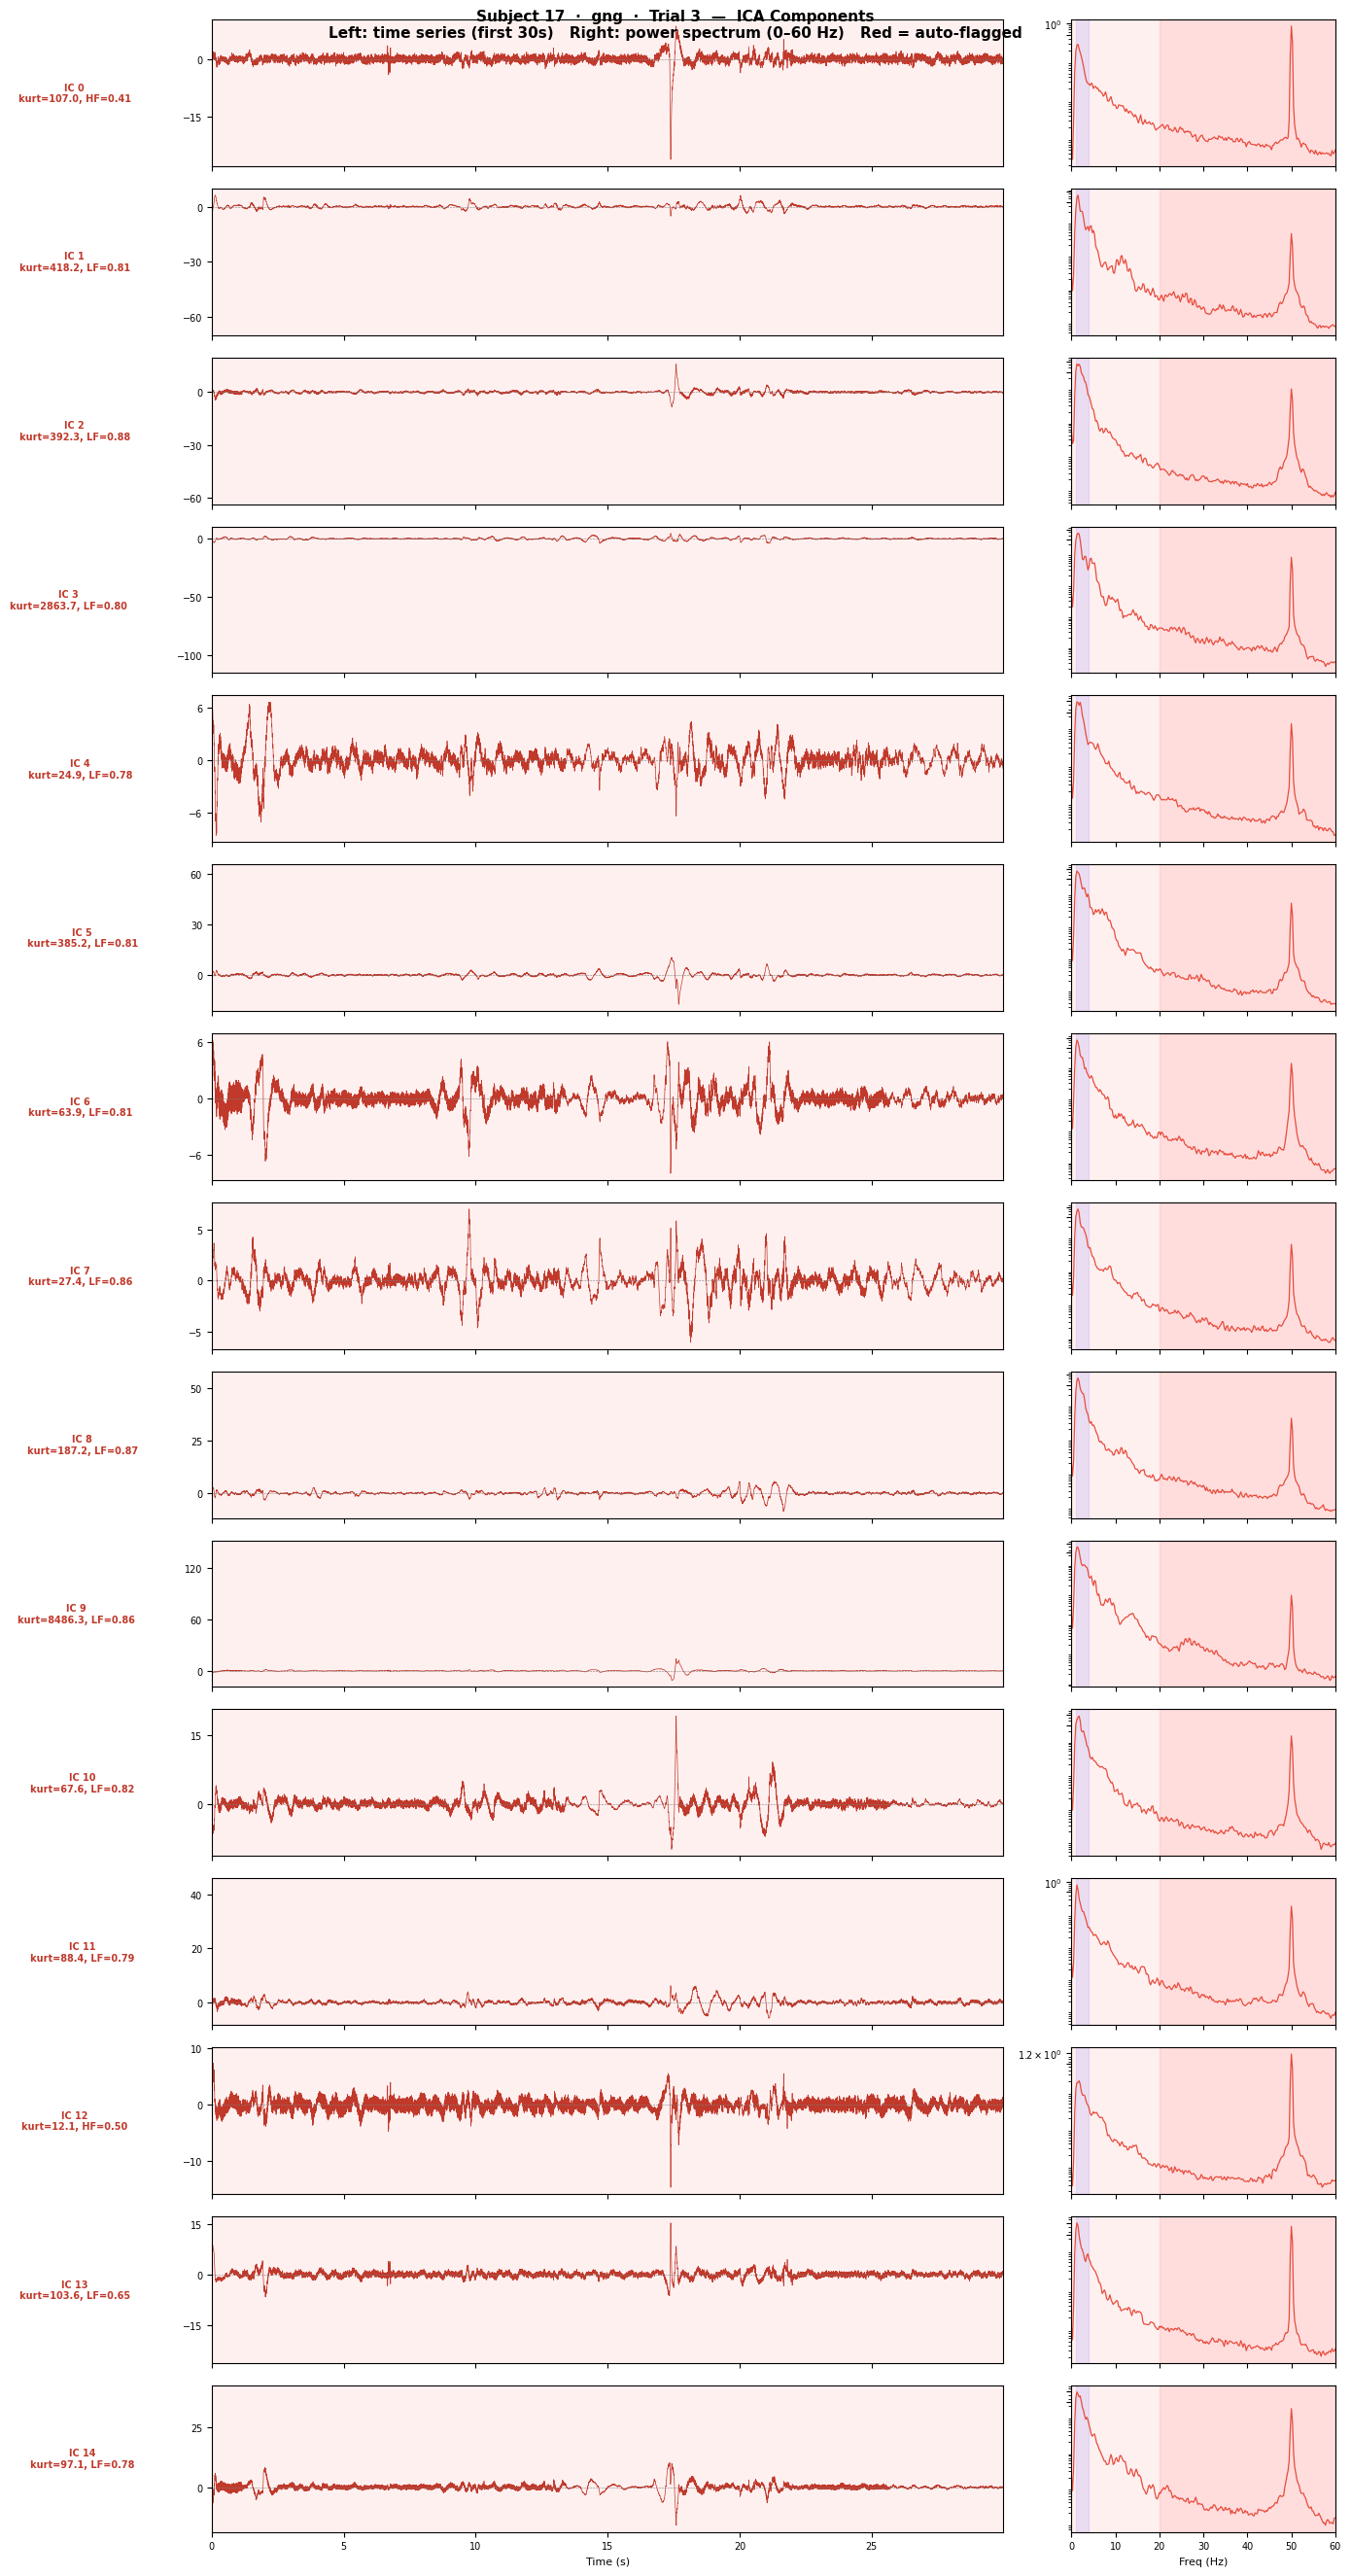

In [ ]:
excluded_log = {}  # trial → list of excluded components

for trial_n in ALL_TRIALS:
    csv_in = DATA_PATH / f"subject_{SUBJECT}_tache_{TACHE}_trial_{trial_n}.csv"
    csv_out = DATA_PATH / f"subject_{SUBJECT}_tache_{TACHE_OUT}_trial_{trial_n}.csv"

    if not csv_in.exists():
        print(f"Trial {trial_n}: not found — skipping")
        continue

    print(f'\n{"="*65}')
    print(f"  Trial {trial_n} / {ALL_TRIALS[-1]}")
    print(f'{"="*65}')

    df = pd.read_csv(csv_in, sep=None, engine="python")
    ts = df["timestamp"].values
    fs = round(len(ts) / (ts[-1] - ts[0]))
    X_raw = df[EEG_COLS].values.astype(np.float64)
    print(
        f"  {len(df)} samples  FS≈{fs} Hz  duration={len(df)/fs:.1f}s  "
        f'presses={int((df["button"].diff().clip(0) > 0).sum())}'
    )

    # High-pass and ICA
    X_hp = hp_filter(X_raw, fs)
    n_comp = min(N_COMP, len(EEG_COLS) - 1)
    print(f"  Fitting ICA ({n_comp} components) …", end="", flush=True)
    S, A, _ = fit_ica(X_hp, n_comp, RANDOM_STATE)
    print(" done.")

    # Auto-flag
    stats = component_stats(S, fs)
    flagged, reasons = auto_flag(stats)
    print(f"\n  Auto-flagged: {flagged}\n")
    print_stats_table(stats, reasons, flagged)

    # Plot (flagged in red)
    plot_components(S, fs, trial_n, flagged, reasons)

    # Prompt — pre-fill with auto suggestion
    suggestion = ",".join(map(str, flagged)) if flagged else ""
    exc_str = input(
        f"\n  Components to exclude "
        f'[auto-suggestion: {suggestion or "none"}] '
        f"(Enter to accept, or type your own list): "
    )
    if exc_str.strip() == "" and flagged:
        exclude = flagged
        print(f"  Accepted auto-suggestion: {exclude}")
    else:
        exclude = sorted(
            {int(x.strip()) for x in exc_str.split(",") if x.strip().isdigit()}
        )

    excluded_log[trial_n] = exclude

    # Apply and save
    X_clean = apply_ica(X_raw, S, A, exclude)
    df_out = df.copy()
    df_out[EEG_COLS] = X_clean
    df_out.to_csv(csv_out, index=False)

    status = f"removed IC{exclude}" if exclude else "no components removed"
    print(f"  → {status}  ·  saved {csv_out.name}")

print("\n" + "=" * 65)
print("  All trials processed.")
print("=" * 65)
print("\nExclusion summary:")
for t, exc in excluded_log.items():
    print(f'  trial {t:2d}: excluded {exc if exc else "none"}')